# Household Power Consumption Forecasting

## Problem Statement and Objective

The objective of this task is to forecast household electricity consumption using time series forecasting and machine learning models.

In this task, we use the Household Power Consumption dataset and predict future values of `Global_active_power`.

Three models are used:

1. ARIMA
2. Prophet
3. XGBoost

The models are compared using MAE and RMSE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from prophet import Prophet

## Dataset Description and Loading

The dataset used in this task is the Household Power Consumption dataset.

It contains household electricity usage recorded at minute-level frequency.

Important columns include:

- Date
- Time
- Global_active_power
- Global_reactive_power
- Voltage
- Global_intensity
- Sub_metering_1
- Sub_metering_2
- Sub_metering_3

For this forecasting task, we mainly use `Global_active_power`.

In [3]:
# Load CSV dataset
data = pd.read_csv(
    "household_power_consumption.csv",
    na_values="?",
    low_memory=False
)

# If data loads as only 1 column, try semicolon separator
if data.shape[1] == 1:
    data = pd.read_csv(
        "household_power_consumption.csv",
        sep=";",
        na_values="?",
        low_memory=False
    )

data.head()

,Datetime,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Date and Time Preprocessing

The dataset has separate Date and Time columns.

These columns are combined into one `Datetime` column and then set as the index.

This is necessary because forecasting models need time-based data.

In [4]:
# Combine Date and Time columns into Datetime
data["Datetime"] = pd.to_datetime(
    data["Date"] + " " + data["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

# Set Datetime as index
data.set_index("Datetime", inplace=True)

# Display updated dataset
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Data Cleaning and Target Selection

In this task, `Global_active_power` is selected as the target variable.

Missing values are handled using interpolation because this is time series data.

In [6]:
# Convert Global_active_power to numeric
data["Global_active_power"] = pd.to_numeric(
    data["Global_active_power"],
    errors="coerce"
)

# Select target column
energy_data = data[["Global_active_power"]].copy()

# Fill missing values using interpolation
energy_data["Global_active_power"] = energy_data["Global_active_power"].interpolate()

# Fill any remaining missing values
energy_data["Global_active_power"] = energy_data["Global_active_power"].ffill().bfill()

# Check missing values again
energy_data.isnull().sum()
# Display energy data
energy_data.head()

,Global_active_power
Datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


## Resampling Time Series Data

The original data is recorded at minute-level frequency.

To make forecasting easier and faster, the data is resampled into hourly average energy usage.

In [7]:
# Resample data into hourly average usage
hourly_data = energy_data.resample("h").mean()

# Fill any missing values after resampling
hourly_data["Global_active_power"] = hourly_data["Global_active_power"].interpolate()
hourly_data["Global_active_power"] = hourly_data["Global_active_power"].ffill().bfill()

# Display hourly data
hourly_data.head()
# Shape of hourly data
print("Hourly data shape:", hourly_data.shape)

Hourly data shape: (34589, 1)


## Exploratory Data Analysis

In this section, we visualize hourly household energy usage to understand the trend and pattern in electricity consumption.

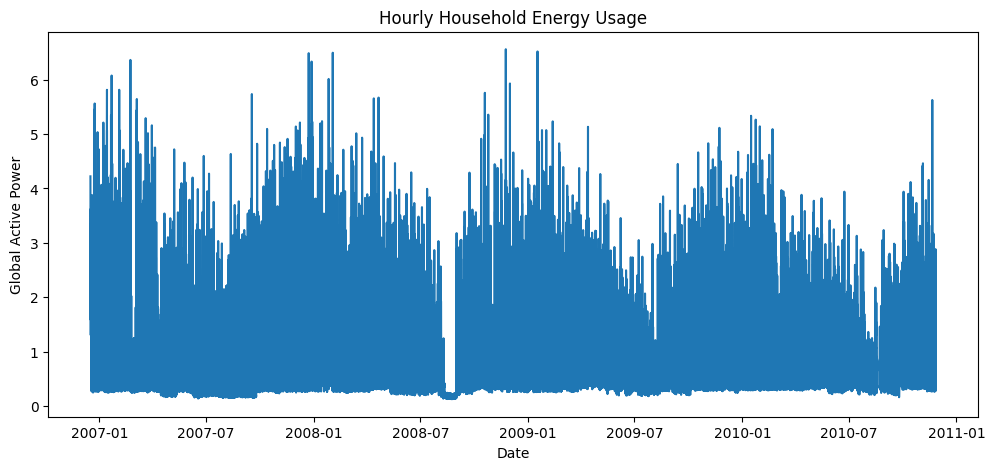

,Global_active_power
count,34589.000000
mean,1.090311
std,0.894323
min,0.124000
25%,0.342867
50%,0.803267
75%,1.578700
max,6.560533


In [8]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_data.index, hourly_data["Global_active_power"])
plt.title("Hourly Household Energy Usage")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.show()
# Statistical summary of hourly data
hourly_data.describe()

## Feature Engineering for XGBoost

XGBoost is a machine learning model, so it needs input features.

Time-based features are created, such as:

- Hour
- Day
- Month
- Weekday
- Weekend indicator

Lag features and rolling mean features are also created to help the model learn previous energy usage patterns.

In [9]:
# Create a copy of hourly data
df = hourly_data.copy()

# Time-based features
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month
df["weekday"] = df.index.weekday

# Weekend feature
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

# Lag features
df["lag_1"] = df["Global_active_power"].shift(1)
df["lag_24"] = df["Global_active_power"].shift(24)
df["lag_48"] = df["Global_active_power"].shift(48)

# Rolling mean features
df["rolling_24"] = df["Global_active_power"].shift(1).rolling(window=24).mean()
df["rolling_48"] = df["Global_active_power"].shift(1).rolling(window=48).mean()

# Remove missing values caused by lag and rolling features
df.dropna(inplace=True)

# Display final feature dataset
df.head()

,Global_active_power,hour,day,month,weekday,is_weekend,lag_1,lag_24,lag_48,rolling_24,rolling_48
Datetime,,,,,,,,,,,
2006-12-18 17:00:00,2.154900,17,18,12,0,0,1.949300,3.406767,4.222889,1.642600,2.070873
2006-12-18 18:00:00,2.402533,18,18,12,0,0,2.154900,3.697100,3.632200,1.590439,2.027790
2006-12-18 19:00:00,2.614500,19,18,12,0,0,2.402533,2.908400,3.400233,1.536499,2.002172
2006-12-18 20:00:00,3.050567,20,18,12,0,0,2.614500,3.361500,3.268567,1.524253,1.985802
2006-12-18 21:00:00,2.169733,21,18,12,0,0,3.050567,3.040767,3.056467,1.511297,1.981260


## Train-Test Split

For time series forecasting, data should not be randomly split.

The last 7 days are used as test data, while the previous data is used for training.

In [10]:
# Use last 7 days as test data
test_size = 24 * 7

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
# Define target column
target_col = "Global_active_power"

# XGBoost features and target
X_train = train.drop(columns=[target_col])
y_train = train[target_col]

X_test = test.drop(columns=[target_col])
y_test = test[target_col]

Train shape: (34373, 11)
Test shape: (168, 11)


## Model Evaluation

The models are evaluated using:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error

Lower values of MAE and RMSE indicate better model performance.

In [11]:
def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    print(f"\n{model_name} Performance:")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")

    return mae, rmse

## ARIMA Model

ARIMA is a statistical time series forecasting model.

It uses past values and differences in the series to predict future values.

In [18]:
# -------------------------------------------------
# 10. ARIMA Model - Corrected Clean Version
# -------------------------------------------------

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Hide ARIMA warnings for clean notebook output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Prepare ARIMA train and test data
arima_train = train[target_col]
arima_test = test[target_col]

print("Training ARIMA model...")

# Build ARIMA model
# A simpler order is more stable and reduces convergence warnings
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train ARIMA model
arima_result = arima_model.fit(method_kwargs={"maxiter": 500})

# Forecast test period
arima_forecast = arima_result.forecast(steps=len(arima_test))

# Align forecast index with test index
arima_forecast = pd.Series(arima_forecast.values, index=test.index)

# Evaluate ARIMA model
arima_mae, arima_rmse = evaluate_model(
    "ARIMA",
    arima_test,
    arima_forecast
)

Training ARIMA model...

ARIMA Performance:
MAE  = 0.6987
RMSE = 0.8593


## Prophet Model

Prophet is a forecasting model developed for time series data.

Prophet requires two columns:

- `ds` for datetime
- `y` for target value

In [13]:
print("Training Prophet model...")

# Prepare Prophet training data
prophet_train = train[[target_col]].reset_index()
prophet_train.columns = ["ds", "y"]

# Prepare Prophet testing data
prophet_test = test[[target_col]].reset_index()
prophet_test.columns = ["ds", "y"]

# Build Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

# Train Prophet model
prophet_model.fit(prophet_train)

# Forecast test dates
future = prophet_test[["ds"]]
prophet_forecast_result = prophet_model.predict(future)

# Extract forecast values
prophet_forecast = pd.Series(
    prophet_forecast_result["yhat"].values,
    index=test.index
)

# Evaluate Prophet
prophet_mae, prophet_rmse = evaluate_model(
    "Prophet",
    prophet_test["y"],
    prophet_forecast
)

Training Prophet model...


18:19:48 - cmdstanpy - INFO - Chain [1] start processing
18:20:11 - cmdstanpy - INFO - Chain [1] done processing



Prophet Performance:
MAE  = 0.5103
RMSE = 0.7550


## XGBoost Model

XGBoost is a machine learning regression model.

It uses time-based features, lag features, and rolling mean features to forecast household power consumption.

In [14]:
print("Training XGBoost model...")

# Build XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict test data
xgb_forecast = xgb_model.predict(X_test)

# Convert forecast to Series with test index
xgb_forecast = pd.Series(xgb_forecast, index=test.index)

# Evaluate XGBoost
xgb_mae, xgb_rmse = evaluate_model(
    "XGBoost",
    y_test,
    xgb_forecast
)

Training XGBoost model...

XGBoost Performance:
MAE  = 0.3684
RMSE = 0.5516


## Model Comparison

The three forecasting models are compared using MAE and RMSE.

In [15]:
# Create results table
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "XGBoost"],
    "MAE": [arima_mae, prophet_mae, xgb_mae],
    "RMSE": [arima_rmse, prophet_rmse, xgb_rmse]
})

# Display results
results
# Save model comparison results
results.to_csv("model_comparison_results.csv", index=False)

print("Model comparison saved as model_comparison_results.csv")

Model comparison saved as model_comparison_results.csv


## Actual vs Forecasted Values

This graph compares the actual energy usage with the forecasted values from ARIMA, Prophet, and XGBoost.

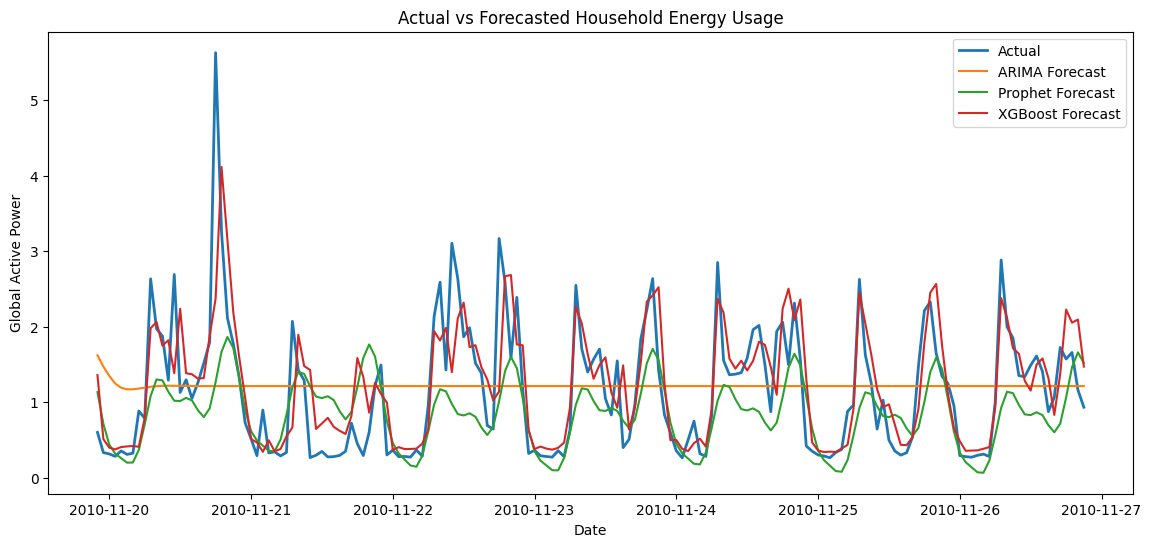

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, y_test, label="Actual", linewidth=2)
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.plot(test.index, prophet_forecast, label="Prophet Forecast")
plt.plot(test.index, xgb_forecast, label="XGBoost Forecast")

plt.title("Actual vs Forecasted Household Energy Usage")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

## Save Forecast Results

The forecast results are saved in a CSV file for reporting and submission.

In [17]:
forecast_results = pd.DataFrame({
    "Datetime": test.index,
    "Actual": y_test.values,
    "ARIMA_Forecast": arima_forecast.values,
    "Prophet_Forecast": prophet_forecast.values,
    "XGBoost_Forecast": xgb_forecast.values
})

forecast_results.to_csv("energy_forecast_results.csv", index=False)

print("Forecast results saved as energy_forecast_results.csv")
print("Model comparison saved as model_comparison_results.csv")

Forecast results saved as energy_forecast_results.csv
Model comparison saved as model_comparison_results.csv


## Final Conclusion

In this task, household electricity consumption was forecasted using ARIMA, Prophet, and XGBoost.

The data was cleaned, converted into datetime format, resampled into hourly average usage, and prepared for forecasting.

ARIMA was used as a statistical time series model. Prophet was used for seasonal forecasting, and XGBoost was used with time-based, lag, and rolling mean features.

The models were evaluated using MAE and RMSE. The model with the lowest MAE and RMSE is considered the best-performing model for this forecasting task.

This task shows how time series forecasting can help predict future household electricity usage and support better energy planning.